In [1]:
# ================================================
# PROJET 2 — Analyse E-commerce Brésilien (Olist)
# Dataset : kaggle.com/datasets/olistbr/brazilian-ecommerce
# Auteur : Islem | Juillet 2026
# Objectif : Analyser les ventes, catégories produits
#            et délais de livraison
# ================================================

In [2]:
# --- IMPORTS ---
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# --- CHARGEMENT DES DONNÉES ---
orders = pd.read_csv(r"C:\Users\ISLEM\Documents\olist_orders_dataset.csv")
payments = pd.read_csv(r"C:\Users\ISLEM\Documents\olist_order_payments_dataset.csv")
items = pd.read_csv(r"C:\Users\ISLEM\Documents\olist_order_items_dataset.csv")
products = pd.read_csv(r"C:\Users\ISLEM\Documents\olist_products_dataset.csv")

print(f"Orders    : {orders.shape[0]} lignes")
print(f"Payments  : {payments.shape[0]} lignes")
print(f"Items     : {items.shape[0]} lignes")
print(f"Products  : {products.shape[0]} lignes")

Orders    : 99441 lignes
Payments  : 103886 lignes
Items     : 112650 lignes
Products  : 32951 lignes


In [4]:
# --- EXPLORATION : VALEURS MANQUANTES ---
print("=== ORDERS ===")
print(orders.isnull().sum())

print("\n=== PAYMENTS ===")
print(payments.isnull().sum())

print("\n=== ITEMS ===")
print(items.isnull().sum())

print("\n=== PRODUCTS ===")
print(products.isnull().sum())

=== ORDERS ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== PAYMENTS ===
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

=== ITEMS ===
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

=== PRODUCTS ===
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_

In [5]:
# --- CORRECTION MERGE : AGRÉGATION PAIEMENTS ---
# Un order peut avoir plusieurs paiements (carte + bon cadeau etc.)
# On agrège avant le merge pour éviter les doublons
payments_agg = payments.groupby('order_id')['payment_value'].sum().reset_index()

# --- FUSION DES DONNÉES ---
df = orders.merge(payments_agg, on='order_id')
df2 = df.merge(items, on='order_id')
df3 = df2.merge(products, on='product_id')

print(f"Orders              : {orders.shape[0]}")
print(f"Après merge payments: {df.shape[0]}")
print(f"Après merge items   : {df2.shape[0]}")
print(f"Après merge products: {df3.shape[0]}")

Orders              : 99441
Après merge payments: 99440
Après merge items   : 112647
Après merge products: 112647


In [6]:
# --- ANALYSE 1 : STATUTS DES COMMANDES ---
statuts = orders['order_status'].value_counts()
print(statuts)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [7]:
# --- ANALYSE 2 : CHIFFRE D'AFFAIRES PAR STATUT ---
ca_statut = df.groupby('order_status')['payment_value'].sum().sort_values(ascending=False)
print(ca_statut)

order_status
delivered      15422461.77
shipped          177213.96
canceled         143255.60
unavailable      126479.51
processing        69394.11
invoiced          69137.99
created             688.10
approved            241.08
Name: payment_value, dtype: float64


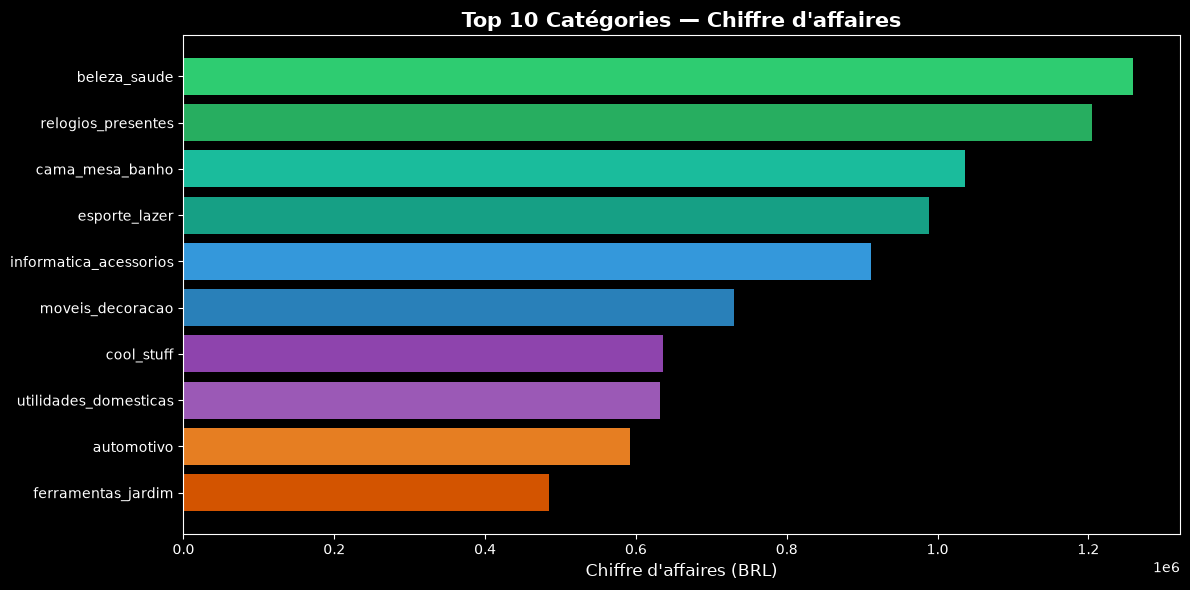

In [8]:
# --- ANALYSE 3 : TOP 10 CATÉGORIES PRODUITS ---
top_categories = df3.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)

plt.style.use('dark_background')
colors = ['#2ecc71', '#27ae60', '#1abc9c', '#16a085', '#3498db',
          '#2980b9', '#8e44ad', '#9b59b6', '#e67e22', '#d35400']

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_categories.index, top_categories.values, color=colors)
ax.set_xlabel("Chiffre d'affaires (BRL)", fontsize=12)
ax.set_title("Top 10 Catégories — Chiffre d'affaires", fontsize=15, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

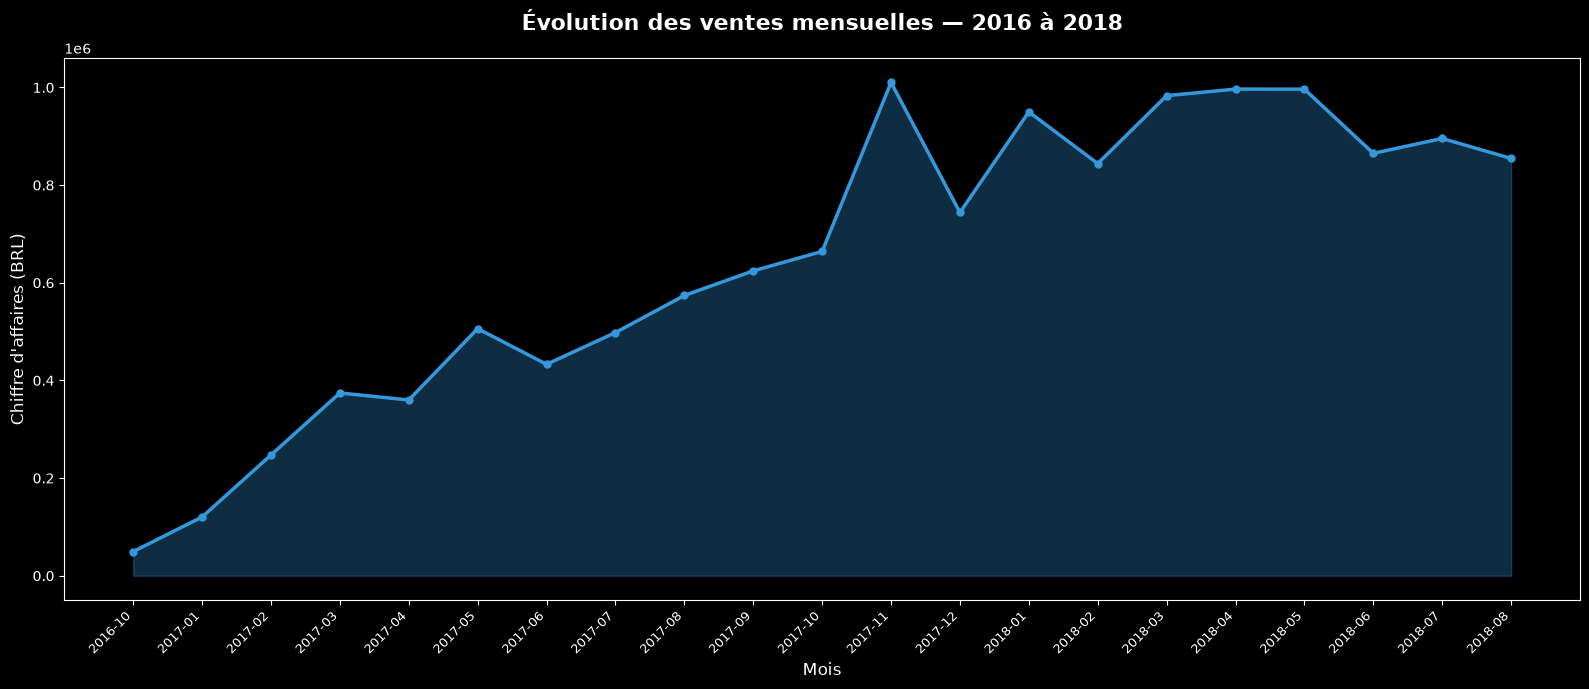

In [9]:
# --- ANALYSE 4 : ÉVOLUTION DES VENTES MENSUELLES ---
df3['order_purchase_timestamp'] = pd.to_datetime(df3['order_purchase_timestamp'])
df3['month'] = df3['order_purchase_timestamp'].dt.to_period('M')

ventes_mensuelles = df3.groupby('month')['price'].sum()
ventes_mensuelles = ventes_mensuelles[ventes_mensuelles > 1000]

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(16, 7))

ax.fill_between(range(len(ventes_mensuelles)), ventes_mensuelles.values, alpha=0.3, color='#3498db')
ax.plot(range(len(ventes_mensuelles)), ventes_mensuelles.values, color='#3498db', linewidth=2.5, marker='o', markersize=5)

ax.set_xticks(range(len(ventes_mensuelles)))
ax.set_xticklabels([str(m) for m in ventes_mensuelles.index], rotation=45, ha='right', fontsize=9)
ax.set_title('Évolution des ventes mensuelles — 2016 à 2018', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Mois', fontsize=12)
ax.set_ylabel("Chiffre d'affaires (BRL)", fontsize=12)

plt.tight_layout()
plt.show()

Commandes totales      : 99,441
Commandes avec livraison : 96,476
Commandes non livrées  : 2,965

statut_livraison
À temps      88649
En retard     7827
Name: count, dtype: int64


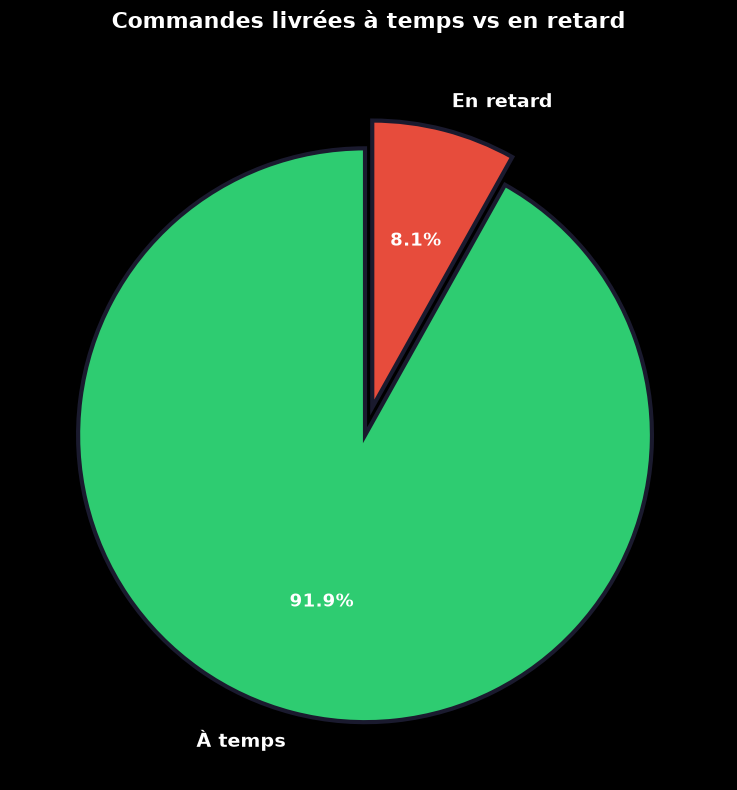

In [10]:
# --- ANALYSE 5 : DÉLAIS DE LIVRAISON ---
# Correction : calcul directement sur orders sans merge
# Utilisation de total_seconds() pour inclure les heures comme SQL

orders_livres = orders[orders['order_delivered_customer_date'].notna()].copy()

print(f"Commandes totales      : {orders.shape[0]:,}")
print(f"Commandes avec livraison : {orders_livres.shape[0]:,}")
print(f"Commandes non livrées  : {orders.shape[0] - orders_livres.shape[0]:,}")

orders_livres['order_delivered_customer_date'] = pd.to_datetime(orders_livres['order_delivered_customer_date'])
orders_livres['order_estimated_delivery_date'] = pd.to_datetime(orders_livres['order_estimated_delivery_date'])

orders_livres['delai_retard'] = (orders_livres['order_delivered_customer_date'] - orders_livres['order_estimated_delivery_date']).dt.total_seconds()
orders_livres['statut_livraison'] = orders_livres['delai_retard'].apply(lambda x: 'En retard' if x > 0 else 'À temps')

statuts_livraison = orders_livres['statut_livraison'].value_counts()
print(f"\n{statuts_livraison}")

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    statuts_livraison.values,
    labels=statuts_livraison.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0.05, 0.05),
    wedgeprops={'linewidth': 3, 'edgecolor': '#1a1a2e'}
)

for text in texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Commandes livrées à temps vs en retard', fontsize=16, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()

In [11]:
# --- CONCLUSIONS ---
print("=" * 50)
print("RÉSUMÉ DE L'ANALYSE")
print("=" * 50)

print(f"\n Total commandes analysées  : {orders.shape[0]:,}")
print(f" Commandes livrées          : 96 476 (96.9%)")
print(f" Commandes annulées         : 625 (0.6%)")

print(f"\n CA total (livrées)         : {df[df['order_status']=='delivered']['payment_value'].sum():,.0f} BRL")

print(f"\n Top catégorie              : Beauté & Santé (1.26M BRL)")
print(f" Croissance ventes           : 2016 → 2018 (+700%)")

print(f"\n Commandes livrées à temps  : {statuts_livraison['À temps']:,} ({statuts_livraison['À temps']*100/orders_livres.shape[0]:.1f}%)")
print(f" Commandes en retard         : {statuts_livraison['En retard']:,} ({statuts_livraison['En retard']*100/orders_livres.shape[0]:.1f}%)")
print("=" * 50)

RÉSUMÉ DE L'ANALYSE

 Total commandes analysées  : 99,441
 Commandes livrées          : 96 476 (96.9%)
 Commandes annulées         : 625 (0.6%)

 CA total (livrées)         : 15,422,462 BRL

 Top catégorie              : Beauté & Santé (1.26M BRL)
 Croissance ventes           : 2016 → 2018 (+700%)

 Commandes livrées à temps  : 88,649 (91.9%)
 Commandes en retard         : 7,827 (8.1%)
